In [ ]:
import numpy as np
!pip install duckdb pandas

In [ ]:
####### Chechpoint 1: To create a common dataset(common table) using joins########

import duckdb
import pandas as pd

con = duckdb.connect()

# Sales 2015
df_sales_2015 = pd.read_csv('Sales_2015.csv', encoding='latin1')
con.execute("CREATE TABLE Sales_2015 AS SELECT * FROM df_sales_2015")

# Sales 2016
df_sales_2016 = pd.read_csv('Sales_2016.csv', encoding='latin1')
con.execute("CREATE TABLE Sales_2016 AS SELECT * FROM df_sales_2016")

# Sales 2017
df_sales_2017 = pd.read_csv('Sales_2017.csv', encoding='latin1')
con.execute("CREATE TABLE Sales_2017 AS SELECT * FROM df_sales_2017")

# Products
df_products = pd.read_csv('Products.csv', encoding='latin1')
con.execute("CREATE TABLE Products AS SELECT * FROM df_products")

# Product Subcategories
df_subcategories = pd.read_csv('Product_Subcategories.csv', encoding='latin1')
con.execute("CREATE TABLE Product_Subcategories AS SELECT * FROM df_subcategories")

# Product Categories
df_categories = pd.read_csv('Product_Categories.csv', encoding='latin1')
con.execute("CREATE TABLE Product_Categories AS SELECT * FROM df_categories")

# Customers (the problematic one)
df_customers = pd.read_csv('Customers.csv', encoding='latin1')
con.execute("CREATE TABLE Customers AS SELECT * FROM df_customers")

# Territories
df_territories = pd.read_csv('Territories.csv', encoding='latin1')
con.execute("CREATE TABLE Territories AS SELECT * FROM df_territories")

df_calendar = pd.read_csv('Calendar.csv', encoding='latin1')
con.execute("CREATE TABLE Calendar AS SELECT * FROM df_calendar")

tables = con.execute("SHOW TABLES").df()
print("Tables loaded:\n", tables)

# Create Master Dataset
con.execute("""
    CREATE TABLE Master_Dataset AS
    SELECT
        -- Sales Info
        s.OrderDate,
        s.StockDate,
        s.OrderNumber,
        s.OrderLineItem,
        s.OrderQuantity,

        -- Customer Info
        c.CustomerKey,
        c.Prefix,
        c.FirstName,
        c.LastName,
        c.BirthDate,
        c.MaritalStatus,
        c.Gender,
        c.EmailAddress,
        c.AnnualIncome,
        c.TotalChildren,
        c.EducationLevel,
        c.Occupation,
        c.HomeOwner,

        -- Territory Info
        t.SalesTerritoryKey,
        t.Region,
        t.Country,
        t.Continent,

        -- Calendar Info
        cal.Date,

        -- Product Info
        p.ProductKey,
        p.ProductSKU,
        p.ProductName,
        p.ModelName,
        p.ProductDescription,
        p.ProductColor,
        p.ProductSize,
        p.ProductStyle,
        p.ProductCost,
        p.ProductPrice,

        -- Subcategory Info
        ps.ProductSubcategoryKey,
        ps.SubcategoryName,

        -- Category Info
        pc.ProductCategoryKey,
        pc.CategoryName

    FROM (
        SELECT * FROM Sales_2015
        UNION ALL
        SELECT * FROM Sales_2016
        UNION ALL
        SELECT * FROM Sales_2017
    ) s

    INNER JOIN Products p
        ON s.ProductKey = p.ProductKey

    INNER JOIN Product_Subcategories ps
        ON p.ProductSubcategoryKey = ps.ProductSubcategoryKey

    INNER JOIN Product_Categories pc
        ON ps.ProductCategoryKey = pc.ProductCategoryKey

    INNER JOIN Customers c
        ON s.CustomerKey = c.CustomerKey

    INNER JOIN Territories t
        ON s.TerritoryKey = t.SalesTerritoryKey

    LEFT JOIN Calendar cal
        ON s.OrderDate = cal.Date
""")


print("\nFirst 10 rows:")
result = con.execute("SELECT * FROM Master_Dataset LIMIT 10").df()
print(result)

count = con.execute("SELECT COUNT(*) FROM Master_Dataset").fetchone()[0]
print(f"\nTotal Rows in Master Dataset: {count}")

print("\nColumns:")
columns = con.execute("DESCRIBE Master_Dataset").df()
print(columns)

con.execute("""
    COPY Master_Dataset TO 'Master_Dataset.csv'
    (HEADER, DELIMITER ',')
""")
print("\nMaster_Dataset.csv exported successfully!")

con.close()

Tables loaded:
                     name
0               Calendar
1              Customers
2     Product_Categories
3  Product_Subcategories
4               Products
5             Sales_2015
6             Sales_2016
7             Sales_2017
8            Territories

First 10 rows:
  OrderDate   StockDate OrderNumber  OrderLineItem  OrderQuantity  \
0  1/1/2015   9/21/2001     SO45080              1              1   
1  1/1/2015   12/5/2001     SO45079              1              1   
2  1/1/2015  10/29/2001     SO45082              1              1   
3  1/1/2015  11/16/2001     SO45081              1              1   
4  1/2/2015  12/15/2001     SO45083              1              1   
5  1/2/2015  10/12/2001     SO45084              1              1   
6  1/2/2015  12/18/2001     SO45086              1              1   
7  1/2/2015   10/9/2001     SO45085              1              1   
8  1/3/2015   10/3/2001     SO45093              1              1   
9  1/3/2015   9/29/2001     

Dataset size: (56046, 37)

Columns present:
['OrderDate', 'StockDate', 'OrderNumber', 'OrderLineItem', 'OrderQuantity', 'CustomerKey', 'Prefix', 'FirstName', 'LastName', 'BirthDate', 'MaritalStatus', 'Gender', 'EmailAddress', 'AnnualIncome', 'TotalChildren', 'EducationLevel', 'Occupation', 'HomeOwner', 'SalesTerritoryKey', 'Region', 'Country', 'Continent', 'Date', 'ProductKey', 'ProductSKU', 'ProductName', 'ModelName', 'ProductDescription', 'ProductColor', 'ProductSize', 'ProductStyle', 'ProductCost', 'ProductPrice', 'ProductSubcategoryKey', 'SubcategoryName', 'ProductCategoryKey', 'CategoryName']

Sample rows:
+---------+----------+-----------+-------------+-------------+-----------+------+---------+----------+----------+-------------+------+--------------------+------------+-------------+---------------+--------------+---------+-----------------+--------------+--------------+-------------+--------+----------+----------+--------------------+------------+--------------------+----------

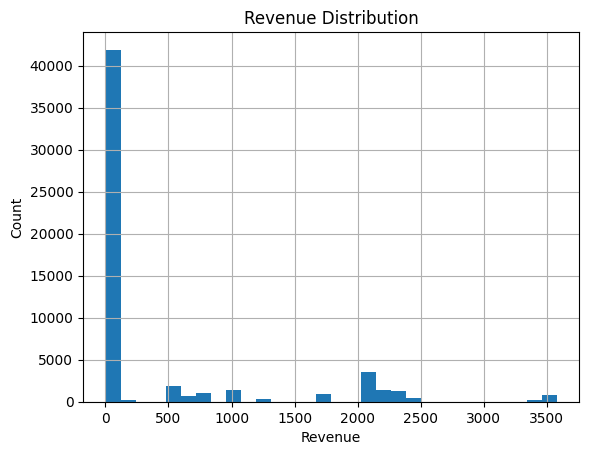

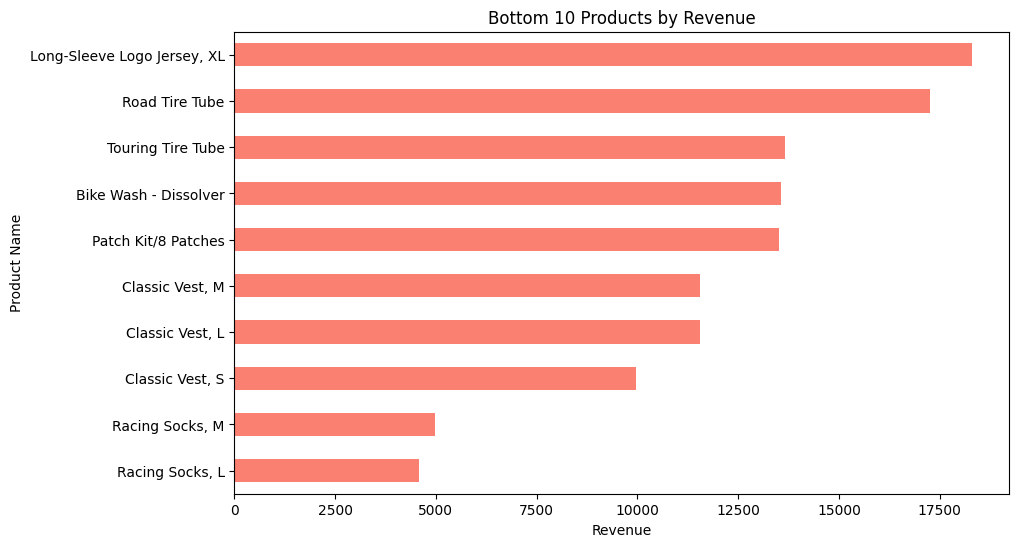

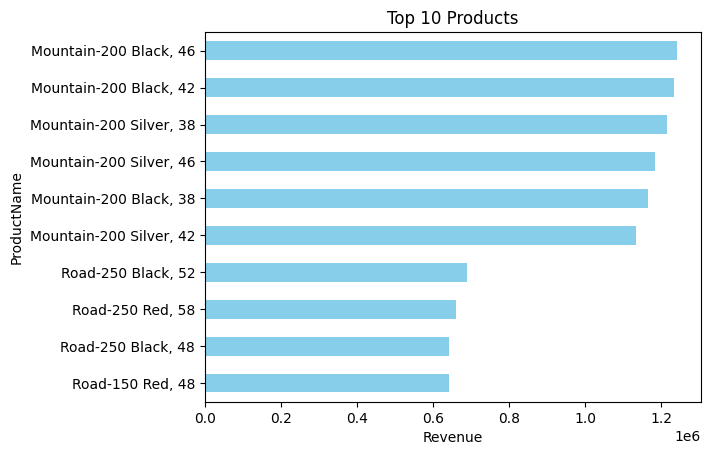

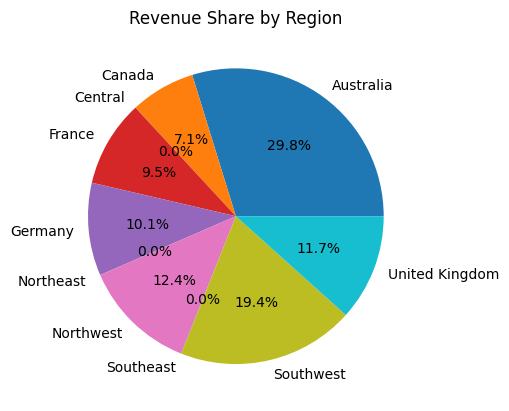

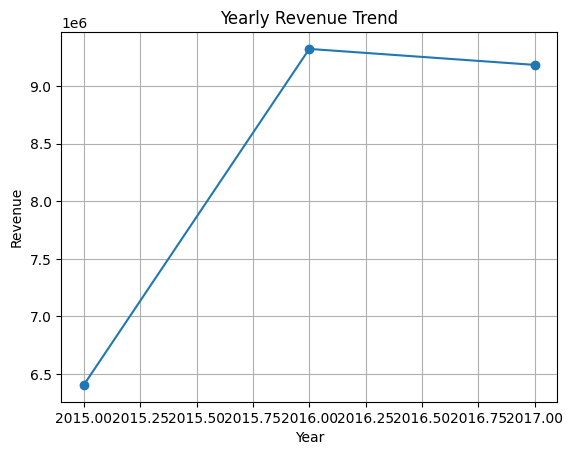

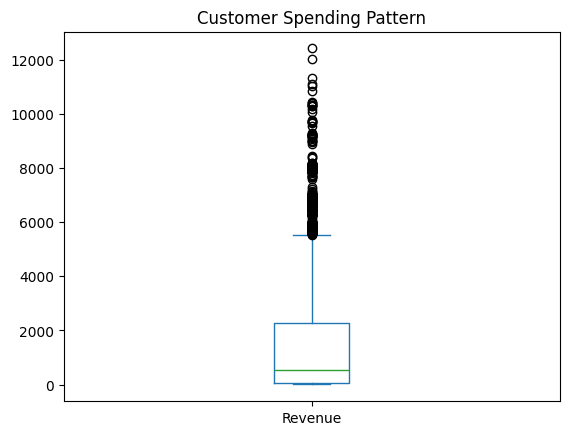

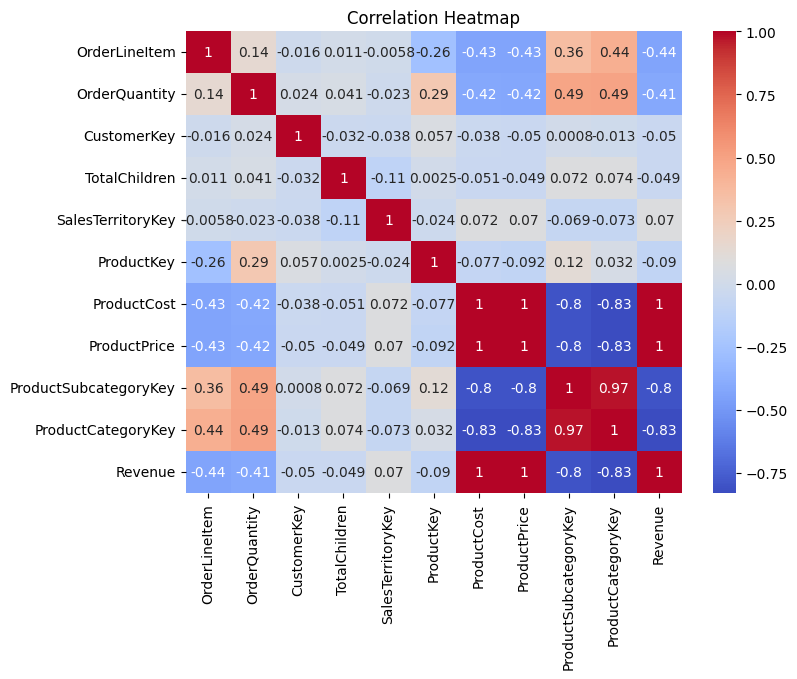

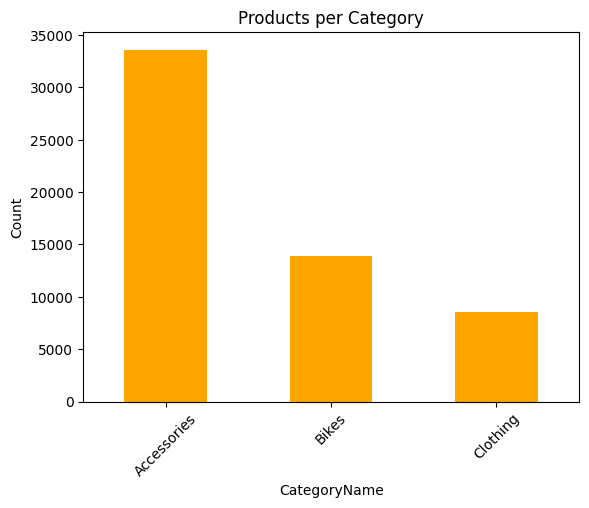

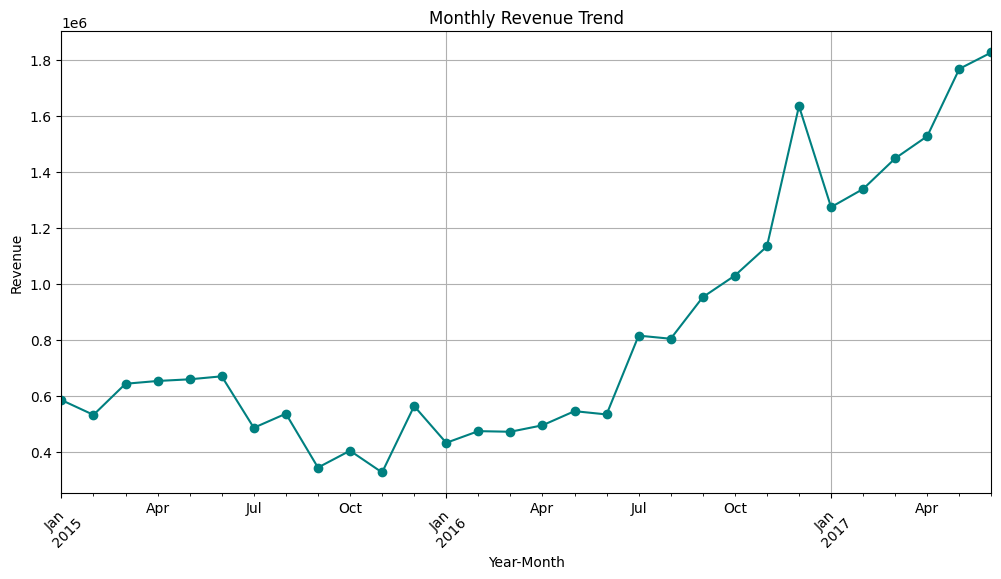

Top 3 categories: ['Bikes', 'Accessories', 'Clothing'] contribute 100.00% of total revenue.


/tmp/ipykernel_4007/3128250144.py:157: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=category_revenue.index, y=category_revenue.values, palette='viridis')


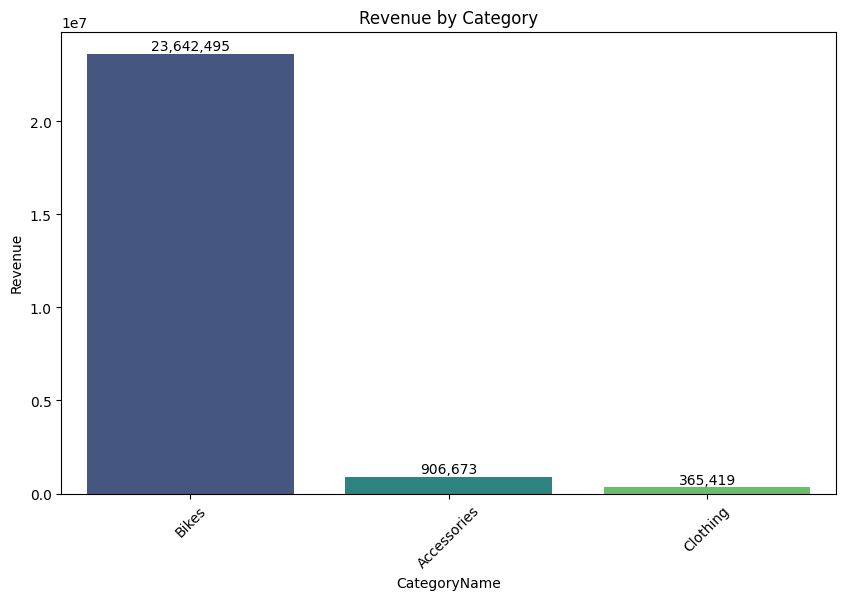

Top 10% customers (1742 customers) contribute 40.36% of revenue.


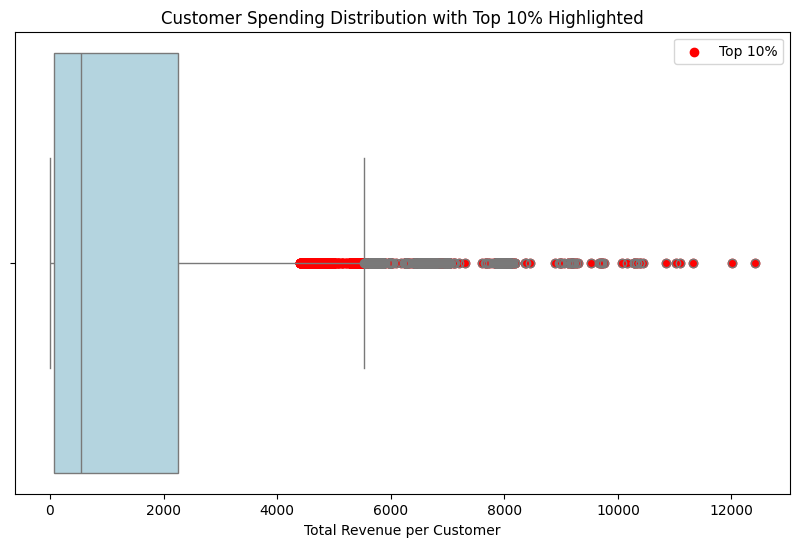

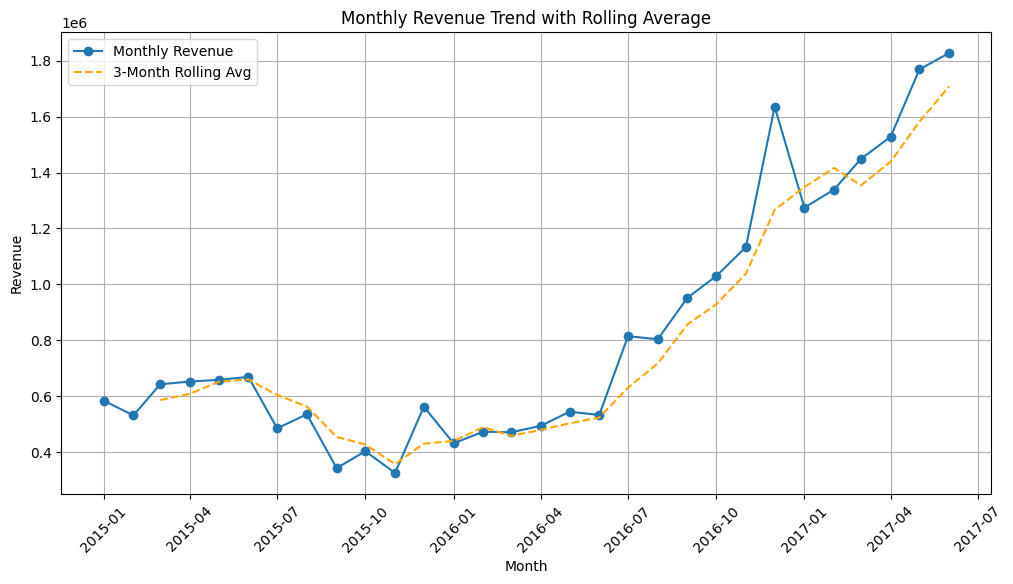

Months with top 10% revenue (seasonal peaks): ['Dec-2016', 'May-2017', 'Jun-2017']


In [ ]:
# Checkpoint 2 :
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, sum, year
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

spark = SparkSession.builder.appName("EDA Work").getOrCreate()
df = spark.read.csv("Master_Dataset.csv", header=True, inferSchema=True)

# 1. basic understanding
print("Dataset size:", (df.count(), len(df.columns)))

print("\nColumns present:")
print(df.columns)

print("\nSample rows:")
df.show(5)

print("\nSchema:")
df.printSchema()

print("\nSummary:")
df.describe().show()

# 2. missing values
print("\nMissing values in each column:")
df.select([sum(col(c).isNull().cast("int")).alias(c) for c in df.columns]).show()

# 3. creating revenue column
if 'ProductPrice' in df.columns:
    df = df.withColumn("Revenue", col("OrderQuantity") * col("ProductPrice"))
elif 'ListPrice' in df.columns:
    df = df.withColumn("Revenue", col("OrderQuantity") * col("ListPrice"))
else:
    print("No price column found")

print("\nRevenue column created")

# convert to pandas for analysis
pdf = df.toPandas()

# 4. revenue distribution
print("\nRevenue stats:")
print(pdf['Revenue'].describe())

plt.figure()
pdf['Revenue'].hist(bins=30)
plt.title("Revenue Distribution")
plt.xlabel("Revenue")
plt.ylabel("Count")
plt.show()

# 5. Least sold products (bottom 10 by Revenue)
least_products = pdf.groupby('ProductName')['Revenue'].sum().sort_values().head(10)

plt.figure(figsize=(10,6))
least_products.plot(kind='barh', color='salmon')
plt.title("Bottom 10 Products by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Product Name")
plt.show()

# 6. top products
top_products = pdf.groupby('ProductName')['Revenue'].sum().sort_values(ascending=False).head(10)

plt.figure()
top_products.sort_values().plot(kind='barh', color='skyblue')
plt.title("Top 10 Products")
plt.xlabel("Revenue")
plt.show()

# 7. region comparison (pie chart)
region_sales = pdf.groupby('Region')['Revenue'].sum()

plt.figure()
region_sales.plot(kind='pie', autopct='%1.1f%%')
plt.title("Revenue Share by Region")
plt.ylabel("")
plt.show()

# 8. yearly trend
pdf['OrderDate'] = pd.to_datetime(pdf['OrderDate'])

yearly_sales = pdf.groupby(pdf['OrderDate'].dt.year)['Revenue'].sum()

plt.figure()
yearly_sales.plot(marker='o')
plt.title("Yearly Revenue Trend")
plt.xlabel("Year")
plt.ylabel("Revenue")
plt.grid(True)
plt.show()

# 9. customer behaviour
plt.figure()
pdf.groupby('CustomerKey')['Revenue'].sum().plot(kind='box')
plt.title("Customer Spending Pattern")
plt.show()

# 10. correlation heatmap
plt.figure(figsize=(8,6))
sns.heatmap(pdf.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

# 11. category count
plt.figure()
pdf['CategoryName'].value_counts().plot(kind='bar', color='orange')
plt.title("Products per Category")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

# 12. Monthly trend
# Standardize mixed date formats
def parse_mixed_dates(date_str):
    for fmt in ("%m-%d-%Y", "%d/%m/%Y", "%d-%m-%Y", "%m/%d/%Y"):
        try:
            return pd.to_datetime(date_str, format=fmt)
        except (ValueError, TypeError):
            continue
    return pd.NaT

pdf['OrderDate'] = pdf['OrderDate'].apply(parse_mixed_dates)

# Drop rows where date couldn't be parsed
pdf = pdf.dropna(subset=['OrderDate'])

# Create Year-Month column
pdf['YearMonth'] = pdf['OrderDate'].dt.to_period('M')

# Group by YearMonth and sum Revenue
monthly_revenue = pdf.groupby('YearMonth')['Revenue'].sum()

# Plot Monthly Revenue Trend
plt.figure(figsize=(12,6))
monthly_revenue.plot(marker='o', color='teal')
plt.title("Monthly Revenue Trend")
plt.xlabel("Year-Month")
plt.ylabel("Revenue")
plt.grid(True)
plt.xticks(rotation=45)
plt.show()


# 13. Top Categories Insight
category_revenue = pdf.groupby('CategoryName')['Revenue'].sum().sort_values(ascending=False)
top_3_categories = category_revenue.head(3)
top_3_pct = top_3_categories.sum() / category_revenue.sum() * 100

print(f"Top 3 categories: {list(top_3_categories.index)} contribute {top_3_pct:.2f}% of total revenue.")

# Visualization (bar with % annotation)
plt.figure(figsize=(10,6))
sns.barplot(x=category_revenue.index, y=category_revenue.values, palette='viridis')
plt.title("Revenue by Category")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
for i, val in enumerate(category_revenue.values):
    plt.text(i, val, f'{val:,.0f}', ha='center', va='bottom')
plt.show()

# 14. Customer segmentation - Top 10% spenders
customer_revenue = pdf.groupby('CustomerKey')['Revenue'].sum()
top_10_pct_threshold = customer_revenue.quantile(0.90)
top_customers = customer_revenue[customer_revenue >= top_10_pct_threshold]

print(f"Top 10% customers ({len(top_customers)} customers) contribute "
      f"{top_customers.sum() / customer_revenue.sum() * 100:.2f}% of revenue.")

# Boxplot of customer spending with top 10% highlighted
plt.figure(figsize=(10,6))
sns.boxplot(x=customer_revenue.values, color='lightblue')
plt.scatter(top_customers.values, [0]*len(top_customers), color='red', label='Top 10%')
plt.title("Customer Spending Distribution with Top 10% Highlighted")
plt.xlabel("Total Revenue per Customer")
plt.legend()
plt.show()

# 15. Monthly revenue seasonality & rolling average
monthly_revenue = pdf.groupby(pdf['OrderDate'].dt.to_period('M'))['Revenue'].sum()
monthly_revenue.index = monthly_revenue.index.to_timestamp()

rolling_avg = monthly_revenue.rolling(window=3).mean()  # 3-month rolling avg

plt.figure(figsize=(12,6))
plt.plot(monthly_revenue.index, monthly_revenue.values, marker='o', label='Monthly Revenue')
plt.plot(rolling_avg.index, rolling_avg.values, color='orange', linestyle='--', label='3-Month Rolling Avg')
plt.title("Monthly Revenue Trend with Rolling Average")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.grid(True)
plt.legend()
plt.show()

# Identify seasonal peaks
peak_months = monthly_revenue[monthly_revenue >= monthly_revenue.quantile(0.90)]
print(f"Months with top 10% revenue (seasonal peaks): {list(peak_months.index.strftime('%b-%Y'))}")

# Detect outliers in Revenue using IQR
Q1 = pdf['Revenue'].quantile(0.25)
Q3 = pdf['Revenue'].quantile(0.75)
IQR = Q3 - Q1
outliers = pdf[(pdf['Revenue'] < Q1 - 1.5*IQR) | (pdf['Revenue'] > Q3 + 1.5*IQR)]
#print(f"Detected {len(outliers)} outlier rows in Revenue.")

# 16.Interactive visual using Plotly
import plotly.express as px

fig = px.line(monthly_revenue, x=monthly_revenue.index, y=monthly_revenue.values,
              title='Interactive Monthly Revenue Trend', labels={'x':'Month', 'y':'Revenue'})
fig.show()

In [ ]:
######## To standardize the date columns
import pandas as pd

pdf = pd.read_csv("Master_Dataset.csv")

# 1. Clean numeric columns
numeric_cols = ['AnnualIncome', 'ProductPrice']

for col in numeric_cols:
    if col in pdf.columns:
        # Remove $ and commas
        pdf[col] = pdf[col].replace(r'[\$,]', '', regex=True)
        # Convert to float
        pdf[col] = pdf[col].astype(float)

# calculate Revenue
if 'OrderQuantity' in pdf.columns and 'ProductPrice' in pdf.columns:
    pdf['Revenue'] = pdf['OrderQuantity'] * pdf['ProductPrice']

# 2. Standardize date columns
date_cols = ['OrderDate', 'StockDate', 'BirthDate']

# multiple date formats
def parse_mixed_dates(date_str):
    for fmt in ("%m-%d-%Y", "%d/%m/%Y", "%d-%m-%Y", "%m/%d/%Y"):
        try:
            return pd.to_datetime(date_str, format=fmt)
        except (ValueError, TypeError):
            continue
    return pd.NaT

for col in date_cols:
    if col in pdf.columns:
        pdf[col] = pdf[col].apply(parse_mixed_dates)

pdf.to_csv("Master_Dataset_Cleaned.csv", index=False)
print("Cleaned dataset saved as Master_Dataset_Cleaned.csv")

Cleaned dataset saved as Master_Dataset_Cleaned.csv


Data loaded successfully!

QUICK KPI SNAPSHOT
----------------------------------------
  Total Revenue        : $24,914,586.82
  Total Profit         : $10,457,715.43
  Profit Margin        : 41.97%
  Total Orders         : 25,164
  Total Customers      : 17,416
  Total Units Sold     : 84,174
  Avg Order Value      : $990.09
  Top Category         : Bikes
  Top Country          : United States
  Best Month           : 2017-06

SECTION 1: CORE KPIs
----------------------------------------
                                Value
Total_Revenue             24914586.82
Total_Cost                14456871.39
Total_Profit              10457715.43
Profit_Margin_Pct               41.97
Total_Orders                 25164.00
Total_Units_Sold             84174.00
Total_Customers              17416.00
Total_Products                 130.00
Avg_Order_Value                990.09
Avg_Revenue_Per_Customer      1430.56
Avg_Units_Per_Order              3.35

SECTION 2: REVENUE OVER TIME
--------------------

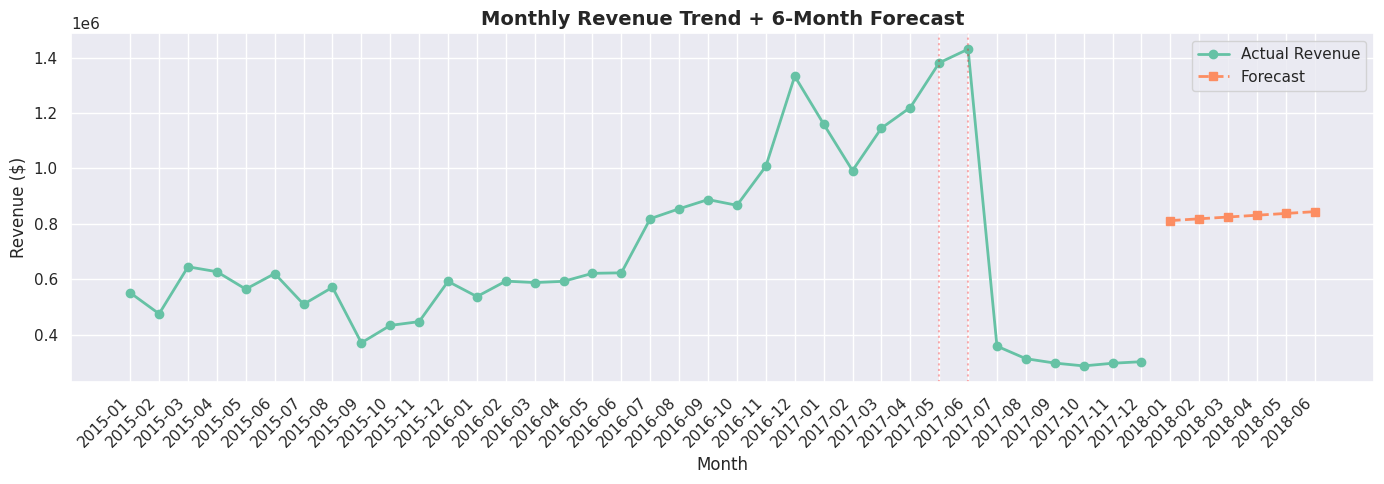

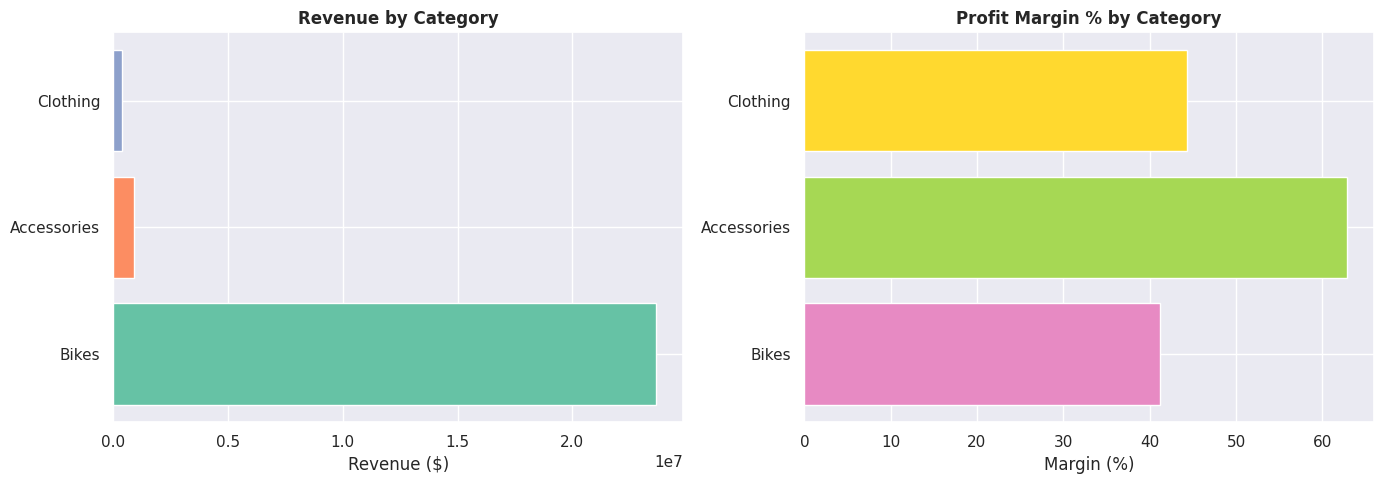

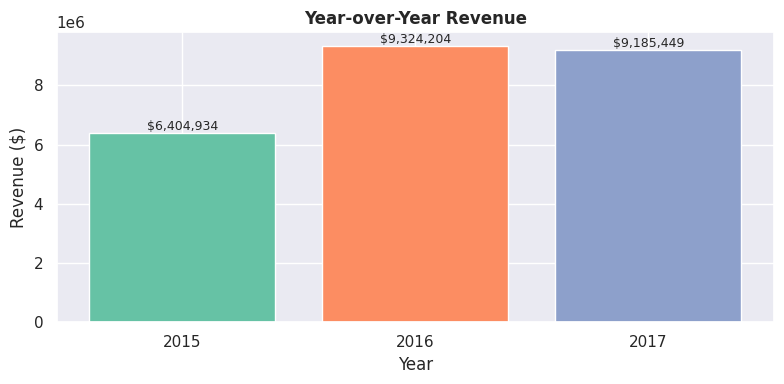

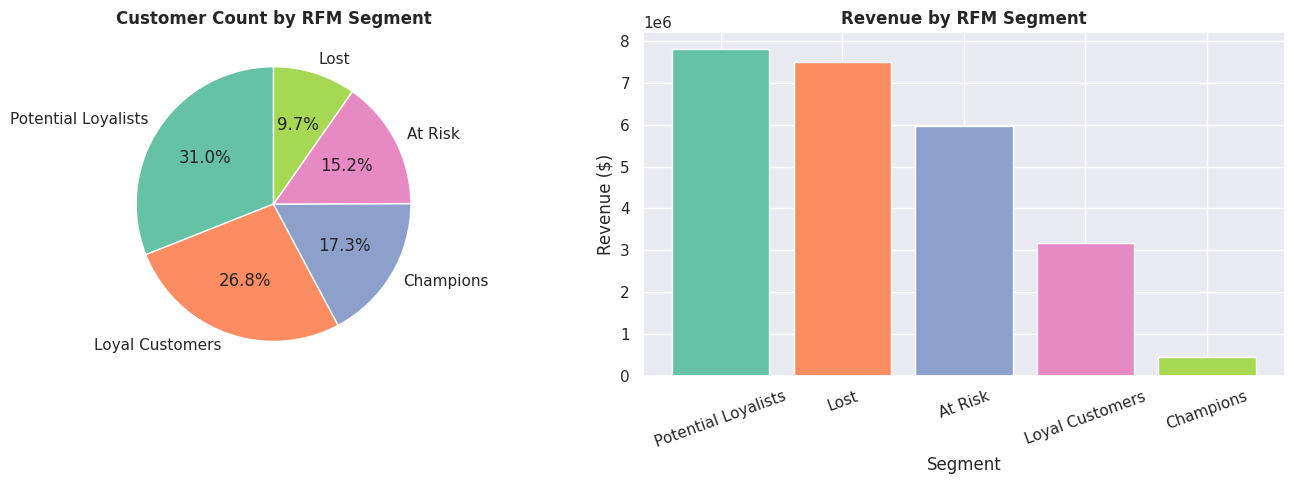

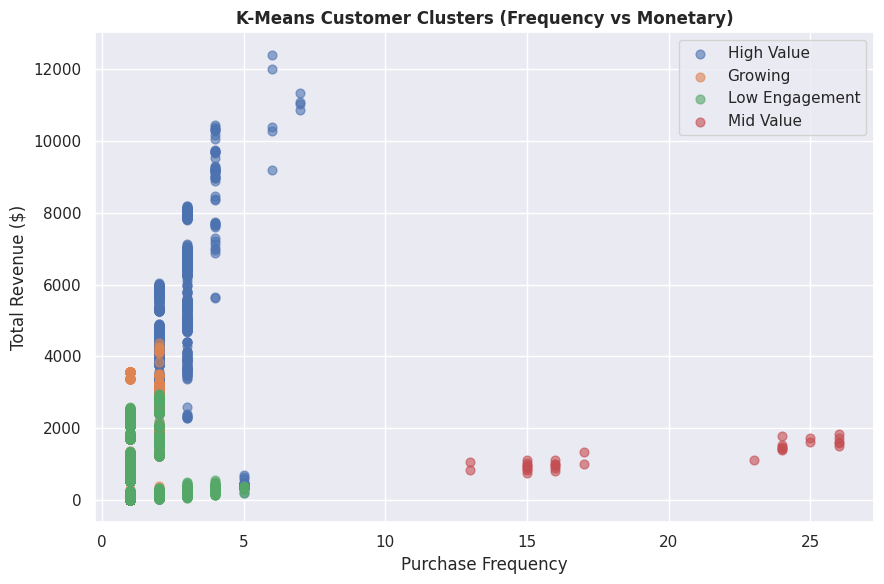

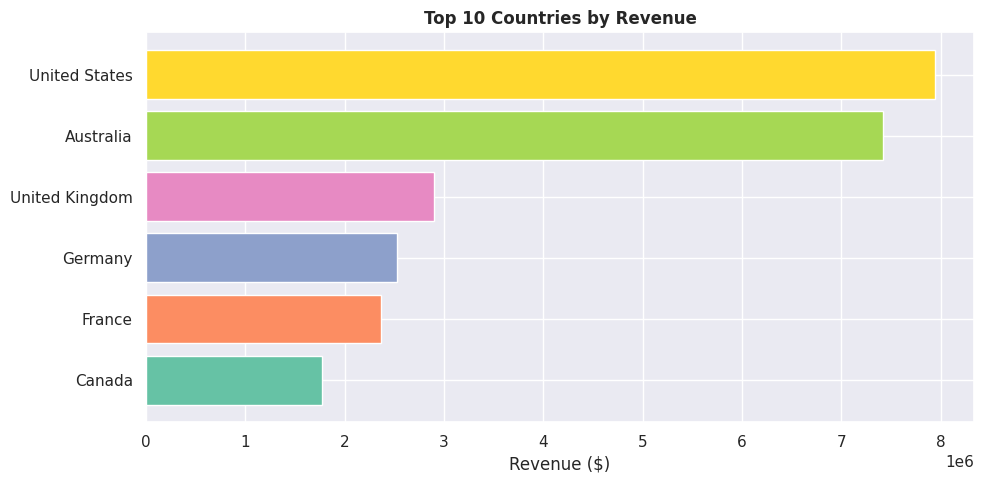

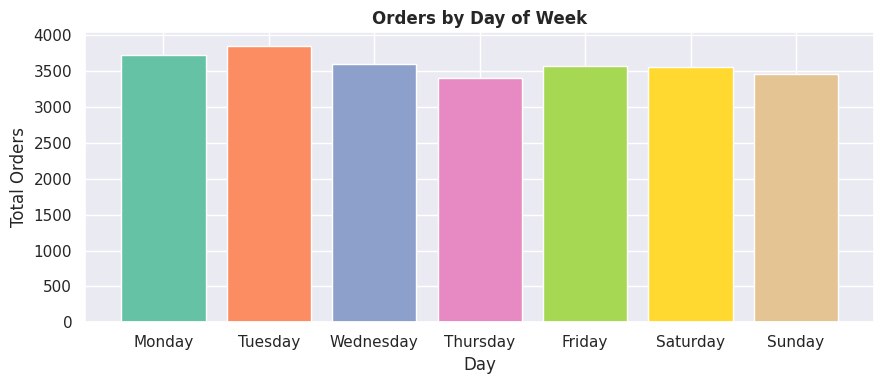

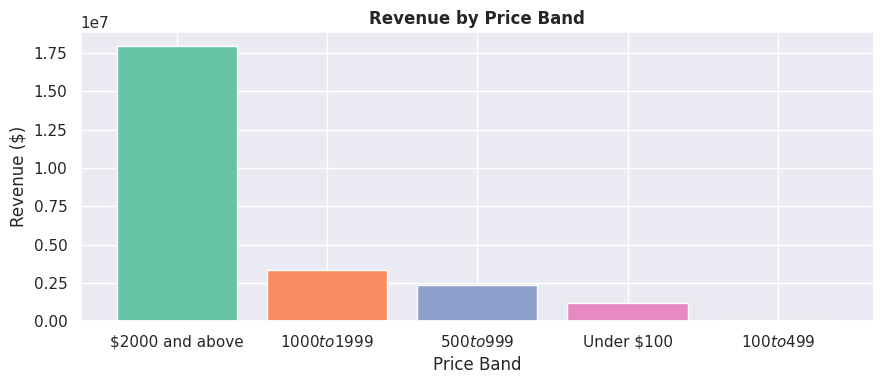

All charts saved.

KPI DESIGN RATIONALE & BUSINESS JUSTIFICATION

Total Revenue & Profit Margin
  WHY        : Revenue shows scale; Margin shows efficiency. Together they reveal whether growth is sustainable or volume-driven.
  DIMENSIONS : Time, Category, Region, Product
  ALERT      : Current margin is 41.97% — benchmark against industry standard of 35-40% for retail.

Average Order Value (AOV)
  WHY        : AOV reveals purchasing behavior. A rising AOV with flat orders means customers are buying more per visit.
  DIMENSIONS : Time, Customer Segment, Geography
  ALERT      : Current AOV: $990.09. Monitor monthly — a drop signals possible discount overuse.

Customer Lifetime Value (CLV)
  WHY        : CLV identifies most valuable customers beyond a single transaction. Drives retention strategy.
  DIMENSIONS : Occupation, Income, Education, Geography
  ALERT      : Top 20 customers drive disproportionate revenue. Protecting these relationships is critical.

RFM Segmentation
  WHY     

In [ ]:
# Checkpoint 3
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Connect to DuckDB in memory
con = duckdb.connect(database=':memory:')

# Load the cleaned master dataset
con.execute("""
CREATE TABLE sales AS
SELECT * FROM read_csv_auto(
    'Master_Dataset_Cleaned.csv',
    delim=',',
    header=True,
    ignore_errors=true,
    null_padding=true
);
""")

# Add numeric income column
con.execute("""
CREATE OR REPLACE TABLE sales AS
SELECT *, TRY_CAST(AnnualIncome AS BIGINT) AS AnnualIncome_Num
FROM sales;
""")

print("Data loaded successfully!")
print("=" * 60)

# QUICK KPI SNAPSHOT
print("\nQUICK KPI SNAPSHOT")
print("-" * 40)

total_revenue   = con.execute("SELECT ROUND(SUM(Revenue), 2) FROM sales").fetchone()[0]
total_profit    = con.execute("SELECT ROUND(SUM(Revenue) - SUM(ProductCost * OrderQuantity), 2) FROM sales").fetchone()[0]
profit_margin   = con.execute("SELECT ROUND((SUM(Revenue) - SUM(ProductCost * OrderQuantity)) * 100.0 / SUM(Revenue), 2) FROM sales").fetchone()[0]
total_orders    = con.execute("SELECT COUNT(DISTINCT OrderNumber) FROM sales").fetchone()[0]
total_customers = con.execute("SELECT COUNT(DISTINCT CustomerKey) FROM sales").fetchone()[0]
total_units     = con.execute("SELECT SUM(OrderQuantity) FROM sales").fetchone()[0]
avg_order_value = con.execute("SELECT ROUND(SUM(Revenue) / COUNT(DISTINCT OrderNumber), 2) FROM sales").fetchone()[0]
top_category    = con.execute("SELECT CategoryName FROM sales GROUP BY CategoryName ORDER BY SUM(Revenue) DESC LIMIT 1").fetchone()[0]
top_country     = con.execute("SELECT Country FROM sales GROUP BY Country ORDER BY SUM(Revenue) DESC LIMIT 1").fetchone()[0]
best_month      = con.execute("SELECT STRFTIME(CAST(OrderDate AS DATE), '%Y-%m') FROM sales GROUP BY 1 ORDER BY SUM(Revenue) DESC LIMIT 1").fetchone()[0]

print(f"  Total Revenue        : ${total_revenue:,.2f}")
print(f"  Total Profit         : ${total_profit:,.2f}")
print(f"  Profit Margin        : {profit_margin}%")
print(f"  Total Orders         : {total_orders:,}")
print(f"  Total Customers      : {total_customers:,}")
print(f"  Total Units Sold     : {total_units:,}")
print(f"  Avg Order Value      : ${avg_order_value:,.2f}")
print(f"  Top Category         : {top_category}")
print(f"  Top Country          : {top_country}")
print(f"  Best Month           : {best_month}")

# SECTION 1: CORE KPIs
print("\nSECTION 1: CORE KPIs")
print("-" * 40)

core_kpis = con.execute("""
SELECT
    ROUND(SUM(Revenue), 2)                                                    AS Total_Revenue,
    ROUND(SUM(ProductCost * OrderQuantity), 2)                                AS Total_Cost,
    ROUND(SUM(Revenue) - SUM(ProductCost * OrderQuantity), 2)                 AS Total_Profit,
    ROUND((SUM(Revenue) - SUM(ProductCost * OrderQuantity)) * 100.0
          / SUM(Revenue), 2)                                                  AS Profit_Margin_Pct,
    COUNT(DISTINCT OrderNumber)                                               AS Total_Orders,
    SUM(OrderQuantity)                                                        AS Total_Units_Sold,
    COUNT(DISTINCT CustomerKey)                                               AS Total_Customers,
    COUNT(DISTINCT ProductKey)                                                AS Total_Products,
    ROUND(SUM(Revenue) / COUNT(DISTINCT OrderNumber), 2)                      AS Avg_Order_Value,
    ROUND(SUM(Revenue) / COUNT(DISTINCT CustomerKey), 2)                      AS Avg_Revenue_Per_Customer,
    ROUND(SUM(OrderQuantity) * 1.0 / COUNT(DISTINCT OrderNumber), 2)          AS Avg_Units_Per_Order
FROM sales;
""").df()
print(core_kpis.T.rename(columns={0: "Value"}))

# SECTION 2: REVENUE OVER TIME
print("\nSECTION 2: REVENUE OVER TIME")
print("-" * 40)

# Revenue grouped by year
yearly = con.execute("""
SELECT
    YEAR(CAST(OrderDate AS DATE))       AS Year,
    SUM(Revenue)                        AS Revenue,
    SUM(OrderQuantity)                  AS Units_Sold,
    COUNT(DISTINCT OrderNumber)         AS Orders,
    COUNT(DISTINCT CustomerKey)         AS Customers
FROM sales
GROUP BY Year
ORDER BY Year;
""").df()
print("\nYearly Summary:\n", yearly)

# Revenue grouped by month
monthly = con.execute("""
SELECT
    STRFTIME(CAST(OrderDate AS DATE), '%Y-%m')  AS YearMonth,
    SUM(Revenue)                                AS Revenue,
    COUNT(DISTINCT OrderNumber)                 AS Orders,
    SUM(OrderQuantity)                          AS Units_Sold
FROM sales
GROUP BY YearMonth
ORDER BY YearMonth;
""").df()
print("\nMonthly Revenue (first 6):\n", monthly.head(6))

# Revenue grouped by quarter
quarterly = con.execute("""
SELECT
    YEAR(CAST(OrderDate AS DATE))       AS Year,
    QUARTER(CAST(OrderDate AS DATE))    AS Quarter,
    SUM(Revenue)                        AS Revenue,
    COUNT(DISTINCT OrderNumber)         AS Orders
FROM sales
GROUP BY Year, Quarter
ORDER BY Year, Quarter;
""").df()
print("\nQuarterly Revenue:\n", quarterly)

# Orders by day of week
day_of_week = con.execute("""
SELECT
    DAYNAME(CAST(OrderDate AS DATE))    AS Day,
    ROUND(AVG(Revenue), 2)              AS Avg_Daily_Revenue,
    COUNT(DISTINCT OrderNumber)         AS Total_Orders
FROM sales
GROUP BY Day
ORDER BY Total_Orders DESC;
""").df()
print("\nRevenue by Day of Week:\n", day_of_week)

# SECTION 3: PRODUCT ANALYSIS
print("\nSECTION 3: PRODUCT ANALYSIS")
print("-" * 40)

# Revenue and profit by product category
category_kpi = con.execute("""
SELECT
    CategoryName,
    SUM(Revenue)                                                        AS Revenue,
    SUM(OrderQuantity)                                                  AS Units_Sold,
    COUNT(DISTINCT OrderNumber)                                         AS Orders,
    ROUND(SUM(Revenue) - SUM(ProductCost * OrderQuantity), 2)           AS Profit,
    ROUND((SUM(Revenue) - SUM(ProductCost * OrderQuantity)) * 100.0
          / SUM(Revenue), 2)                                            AS Profit_Margin_Pct,
    ROUND(SUM(Revenue) * 100.0 / SUM(SUM(Revenue)) OVER (), 2)          AS Revenue_Share_Pct
FROM sales
GROUP BY CategoryName
ORDER BY Revenue DESC;
""").df()
print("\nCategory KPIs:\n", category_kpi)

# Revenue by subcategory
subcategory_kpi = con.execute("""
SELECT
    SubcategoryName,
    CategoryName,
    SUM(Revenue)                                                        AS Revenue,
    SUM(OrderQuantity)                                                  AS Units_Sold,
    ROUND(SUM(Revenue) - SUM(ProductCost * OrderQuantity), 2)           AS Profit,
    ROUND(SUM(Revenue) * 100.0 / SUM(SUM(Revenue)) OVER (), 2)          AS Revenue_Share_Pct
FROM sales
GROUP BY SubcategoryName, CategoryName
ORDER BY Revenue DESC;
""").df()
print("\nTop 10 Subcategories:\n", subcategory_kpi.head(10))

# Top 15 products by revenue
top_products = con.execute("""
SELECT
    ProductName,
    CategoryName,
    SUM(Revenue)                                                        AS Revenue,
    SUM(OrderQuantity)                                                  AS Units_Sold,
    ROUND(SUM(Revenue) - SUM(ProductCost * OrderQuantity), 2)           AS Profit,
    ROUND(AVG(ProductPrice), 2)                                         AS Avg_Price
FROM sales
GROUP BY ProductName, CategoryName
ORDER BY Revenue DESC
LIMIT 15;
""").df()
print("\nTop 15 Products by Revenue:\n", top_products)

# Bottom 10 products by revenue
bottom_products = con.execute("""
SELECT
    ProductName,
    CategoryName,
    SUM(Revenue)        AS Revenue,
    SUM(OrderQuantity)  AS Units_Sold
FROM sales
GROUP BY ProductName, CategoryName
ORDER BY Revenue ASC
LIMIT 10;
""").df()
print("\nBottom 10 Products:\n", bottom_products)

# Revenue split by product price range
price_band = con.execute("""
SELECT
    CASE
        WHEN ProductPrice < 100  THEN 'Under $100'
        WHEN ProductPrice < 500  THEN '$100 to $499'
        WHEN ProductPrice < 1000 THEN '$500 to $999'
        WHEN ProductPrice < 2000 THEN '$1000 to $1999'
        ELSE '$2000 and above'
    END                         AS Price_Band,
    COUNT(DISTINCT ProductKey)  AS Products,
    SUM(Revenue)                AS Revenue,
    SUM(OrderQuantity)          AS Units_Sold
FROM sales
GROUP BY Price_Band
ORDER BY Revenue DESC;
""").df()
print("\nRevenue by Price Band:\n", price_band)

# SECTION 4: CUSTOMER ANALYSIS
print("\nSECTION 4: CUSTOMER ANALYSIS")
print("-" * 40)

# Revenue by customer occupation
customer_segments = con.execute("""
SELECT
    Occupation,
    COUNT(DISTINCT CustomerKey)                                         AS Customers,
    ROUND(SUM(Revenue), 2)                                              AS Revenue,
    ROUND(AVG(Revenue), 2)                                              AS Avg_Revenue,
    ROUND(SUM(Revenue) * 100.0 / SUM(SUM(Revenue)) OVER (), 2)          AS Revenue_Share_Pct
FROM sales
GROUP BY Occupation
ORDER BY Revenue DESC;
""").df()
print("\nCustomers by Occupation:\n", customer_segments)

# Revenue split by gender
gender_analysis = con.execute("""
SELECT
    Gender,
    COUNT(DISTINCT CustomerKey)     AS Customers,
    ROUND(SUM(Revenue), 2)          AS Revenue,
    ROUND(AVG(Revenue), 2)          AS Avg_Revenue
FROM sales
WHERE Gender IS NOT NULL AND Gender != 'NA'
GROUP BY Gender
ORDER BY Revenue DESC;
""").df()
print("\nGender Analysis:\n", gender_analysis)

# Revenue by marital status
marital_analysis = con.execute("""
SELECT
    CASE WHEN MaritalStatus = 'M' THEN 'Married' ELSE 'Single' END     AS Marital_Status,
    COUNT(DISTINCT CustomerKey)                                         AS Customers,
    ROUND(SUM(Revenue), 2)                                              AS Revenue,
    ROUND(AVG(Revenue), 2)                                              AS Avg_Revenue
FROM sales
GROUP BY Marital_Status
ORDER BY Revenue DESC;
""").df()
print("\nMarital Status Analysis:\n", marital_analysis)

# Revenue by education level
education_analysis = con.execute("""
SELECT
    EducationLevel,
    COUNT(DISTINCT CustomerKey)     AS Customers,
    ROUND(SUM(Revenue), 2)          AS Revenue,
    ROUND(AVG(Revenue), 2)          AS Avg_Revenue
FROM sales
GROUP BY EducationLevel
ORDER BY Revenue DESC;
""").df()
print("\nEducation Level Analysis:\n", education_analysis)

# Revenue by home ownership status
homeowner_analysis = con.execute("""
SELECT
    CASE WHEN HomeOwner = 'Y' THEN 'Home Owner' ELSE 'Non-Owner' END   AS Home_Status,
    COUNT(DISTINCT CustomerKey)                                         AS Customers,
    ROUND(SUM(Revenue), 2)                                              AS Revenue,
    ROUND(AVG(Revenue), 2)                                              AS Avg_Revenue
FROM sales
GROUP BY Home_Status
ORDER BY Revenue DESC;
""").df()
print("\nHome Ownership Analysis:\n", homeowner_analysis)

# Top 20 customers by total lifetime value
clv = con.execute("""
SELECT
    CustomerKey,
    FirstName || ' ' || LastName    AS Customer_Name,
    COUNT(DISTINCT OrderNumber)     AS Total_Orders,
    SUM(OrderQuantity)              AS Total_Units,
    ROUND(SUM(Revenue), 2)          AS Lifetime_Value,
    ROUND(AVG(Revenue), 2)          AS Avg_Order_Value,
    MIN(OrderDate)                  AS First_Purchase,
    MAX(OrderDate)                  AS Last_Purchase
FROM sales
GROUP BY CustomerKey, FirstName, LastName
ORDER BY Lifetime_Value DESC
LIMIT 20;
""").df()
print("\nTop 20 Customers by Lifetime Value:\n", clv)

# SECTION 5: GEOGRAPHIC ANALYSIS
print("\nSECTION 5: GEOGRAPHIC ANALYSIS")
print("-" * 40)

# Revenue by continent
continent_kpi = con.execute("""
SELECT
    Continent,
    SUM(Revenue)                                                        AS Revenue,
    COUNT(DISTINCT CustomerKey)                                         AS Customers,
    COUNT(DISTINCT OrderNumber)                                         AS Orders,
    ROUND(SUM(Revenue) * 100.0 / SUM(SUM(Revenue)) OVER (), 2)          AS Revenue_Share_Pct
FROM sales
GROUP BY Continent
ORDER BY Revenue DESC;
""").df()
print("\nRevenue by Continent:\n", continent_kpi)

# Revenue by country
country_kpi = con.execute("""
SELECT
    Country,
    Continent,
    SUM(Revenue)                    AS Revenue,
    COUNT(DISTINCT CustomerKey)     AS Customers,
    COUNT(DISTINCT OrderNumber)     AS Orders,
    ROUND(AVG(Revenue), 2)          AS Avg_Order_Value
FROM sales
GROUP BY Country, Continent
ORDER BY Revenue DESC;
""").df()
print("\nRevenue by Country:\n", country_kpi)

# Revenue by region
region_kpi = con.execute("""
SELECT
    Region,
    Country,
    SUM(Revenue)                    AS Revenue,
    COUNT(DISTINCT CustomerKey)     AS Customers,
    COUNT(DISTINCT OrderNumber)     AS Orders
FROM sales
GROUP BY Region, Country
ORDER BY Revenue DESC;
""").df()
print("\nRevenue by Region:\n", region_kpi)

# SECTION 6: GROWTH & TREND ANALYSIS
print("\nSECTION 6: GROWTH & TREND ANALYSIS")
print("-" * 40)

# Month over month revenue growth with rolling average
monthly_growth = con.execute("""
WITH monthly AS (
    SELECT
        STRFTIME(CAST(OrderDate AS DATE), '%Y-%m')  AS month,
        SUM(Revenue)                                AS revenue
    FROM sales
    GROUP BY month
)
SELECT
    month,
    ROUND(revenue, 2)                                                                       AS Revenue,
    ROUND(LAG(revenue) OVER (ORDER BY month), 2)                                            AS Prev_Month_Revenue,
    ROUND((revenue - LAG(revenue) OVER (ORDER BY month)) * 100.0
          / LAG(revenue) OVER (ORDER BY month), 2)                                          AS MoM_Growth_Pct,
    ROUND(AVG(revenue) OVER (ORDER BY month ROWS BETWEEN 2 PRECEDING AND CURRENT ROW), 2)   AS Rolling_3M_Avg
FROM monthly
ORDER BY month;
""").df()
print("\nMonthly Growth:\n", monthly_growth)

# Year over year revenue growth
yoy_growth = con.execute("""
WITH yearly AS (
    SELECT
        YEAR(CAST(OrderDate AS DATE))   AS year,
        SUM(Revenue)                    AS revenue
    FROM sales
    GROUP BY year
)
SELECT
    year,
    ROUND(revenue, 2)                                                           AS Revenue,
    ROUND(LAG(revenue) OVER (ORDER BY year), 2)                                 AS Prev_Year_Revenue,
    ROUND((revenue - LAG(revenue) OVER (ORDER BY year)) * 100.0
          / LAG(revenue) OVER (ORDER BY year), 2)                               AS YoY_Growth_Pct
FROM yearly
ORDER BY year;
""").df()
print("\nYear-over-Year Growth:\n", yoy_growth)

# SECTION 7: PROFITABILITY ANALYSIS
print("\nSECTION 7: PROFITABILITY ANALYSIS")
print("-" * 40)

# Profit and margin by product category
profit_by_category = con.execute("""
SELECT
    CategoryName,
    ROUND(SUM(Revenue), 2)                                              AS Revenue,
    ROUND(SUM(ProductCost * OrderQuantity), 2)                          AS Total_Cost,
    ROUND(SUM(Revenue) - SUM(ProductCost * OrderQuantity), 2)           AS Profit,
    ROUND((SUM(Revenue) - SUM(ProductCost * OrderQuantity)) * 100.0
          / SUM(Revenue), 2)                                            AS Profit_Margin_Pct
FROM sales
GROUP BY CategoryName
ORDER BY Profit DESC;
""").df()
print("\nProfitability by Category:\n", profit_by_category)

# Profit and margin by region
profit_by_region = con.execute("""
SELECT
    Region,
    ROUND(SUM(Revenue), 2)                                              AS Revenue,
    ROUND(SUM(Revenue) - SUM(ProductCost * OrderQuantity), 2)           AS Profit,
    ROUND((SUM(Revenue) - SUM(ProductCost * OrderQuantity)) * 100.0
          / SUM(Revenue), 2)                                            AS Profit_Margin_Pct
FROM sales
GROUP BY Region
ORDER BY Profit DESC;
""").df()
print("\nProfitability by Region:\n", profit_by_region)

# SECTION 8: RFM CUSTOMER SEGMENTATION
print("\nSECTION 8: RFM CUSTOMER SEGMENTATION")
print("-" * 40)

rfm = con.execute("""
WITH max_date AS (
    SELECT MAX(CAST(OrderDate AS DATE)) AS last_date FROM sales
),
rfm_raw AS (
    SELECT
        s.CustomerKey,
        FirstName || ' ' || LastName                                        AS Customer_Name,
        DATEDIFF('day', MAX(CAST(s.OrderDate AS DATE)), m.last_date)        AS Recency,
        COUNT(DISTINCT s.OrderNumber)                                       AS Frequency,
        ROUND(SUM(s.Revenue), 2)                                            AS Monetary
    FROM sales s, max_date m
    GROUP BY s.CustomerKey, FirstName, LastName, m.last_date
)
SELECT
    CustomerKey,
    Customer_Name,
    Recency,
    Frequency,
    Monetary,
    NTILE(5) OVER (ORDER BY Recency ASC)    AS R_Score,
    NTILE(5) OVER (ORDER BY Frequency DESC) AS F_Score,
    NTILE(5) OVER (ORDER BY Monetary DESC)  AS M_Score
FROM rfm_raw
ORDER BY Monetary DESC;
""").df()

rfm['RFM_Score'] = rfm['R_Score'] + rfm['F_Score'] + rfm['M_Score']

def rfm_label(score):
    if score >= 13:   return 'Champions'
    elif score >= 10: return 'Loyal Customers'
    elif score >= 7:  return 'Potential Loyalists'
    elif score >= 5:  return 'At Risk'
    else:             return 'Lost'

rfm['Segment'] = rfm['RFM_Score'].apply(rfm_label)

rfm_summary = rfm.groupby('Segment').agg(
    Customers     = ('CustomerKey', 'count'),
    Avg_Recency   = ('Recency',     'mean'),
    Avg_Frequency = ('Frequency',   'mean'),
    Avg_Monetary  = ('Monetary',    'mean'),
    Total_Revenue = ('Monetary',    'sum')
).round(2).reset_index().sort_values('Total_Revenue', ascending=False)

print("\nRFM Segments Summary:\n", rfm_summary)
print("\nTop 10 Champion Customers:")
print(rfm[rfm['Segment'] == 'Champions'][['Customer_Name', 'Recency', 'Frequency', 'Monetary']].head(10))

# 9)K-means clustering
print("\nSECTION 9: K-MEANS CUSTOMER CLUSTERING")
print("-" * 40)

scaler     = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm[['Recency', 'Frequency', 'Monetary']])

kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

cluster_summary = rfm.groupby('Cluster').agg(
    Customers     = ('CustomerKey', 'count'),
    Avg_Recency   = ('Recency',     'mean'),
    Avg_Frequency = ('Frequency',   'mean'),
    Avg_Monetary  = ('Monetary',    'mean'),
    Total_Revenue = ('Monetary',    'sum')
).round(2).reset_index().sort_values('Avg_Monetary', ascending=False)

cluster_summary['Cluster_Label'] = ['High Value', 'Mid Value', 'Growing', 'Low Engagement']
print("\nK-Means Cluster Summary:\n", cluster_summary)

label_map           = cluster_summary.set_index('Cluster')['Cluster_Label'].to_dict()
rfm['Cluster_Label'] = rfm['Cluster'].map(label_map)

# 10) Revenue Forecasting
print("\nSECTION 10: REVENUE FORECASTING")
print("-" * 40)

monthly_rev              = monthly[['YearMonth', 'Revenue']].copy()
monthly_rev['Month_Index'] = range(len(monthly_rev))

X = monthly_rev[['Month_Index']].values
y = monthly_rev['Revenue'].values

model = LinearRegression()
model.fit(X, y)

last_idx      = monthly_rev['Month_Index'].max()
last_month    = pd.to_datetime(monthly_rev['YearMonth'].iloc[-1])
future_months = pd.date_range(last_month + pd.DateOffset(months=1), periods=6, freq='MS')
future_idx    = np.arange(last_idx + 1, last_idx + 7).reshape(-1, 1)
forecast      = model.predict(future_idx)

forecast_df = pd.DataFrame({
    'YearMonth':           future_months.strftime('%Y-%m'),
    'Forecasted_Revenue':  np.round(forecast, 2),
    'Type':                'Forecast'
})
monthly_rev['Type'] = 'Actual'

print(f"\nMonthly Revenue Growth Rate : ${model.coef_[0]:,.2f} per month")
print(f"R² Score                    : {model.score(X, y):.4f}")
print("\nNext 6 Months Forecast:\n", forecast_df.to_string(index=False))

# 12) Anomaly Detection
print("\nSECTION 11: ANOMALY DETECTION")
print("-" * 40)

monthly_rev['Z_Score'] = (
    (monthly_rev['Revenue'] - monthly_rev['Revenue'].mean())
    / monthly_rev['Revenue'].std()
)
monthly_rev['Anomaly'] = monthly_rev['Z_Score'].abs() > 2

anomalies = monthly_rev[monthly_rev['Anomaly']][['YearMonth', 'Revenue', 'Z_Score']]

if len(anomalies):
    print("\nAnomalous Revenue Months Detected:\n", anomalies.to_string(index=False))
else:
    print("\nNo significant monthly revenue anomalies detected.")

product_rev = con.execute("""
SELECT ProductName, SUM(Revenue) AS Revenue
FROM sales
GROUP BY ProductName
ORDER BY Revenue DESC;
""").df()

product_rev['Z_Score']   = (product_rev['Revenue'] - product_rev['Revenue'].mean()) / product_rev['Revenue'].std()
product_outliers          = product_rev[product_rev['Z_Score'].abs() > 2]

print(f"\nOutlier Products ({len(product_outliers)} found):")
print(product_outliers[['ProductName', 'Revenue', 'Z_Score']].to_string(index=False))

# 12) Visualisations
print("\nSECTION 12: VISUALIZATIONS...")
print("-" * 40)

sns.set_theme(style="darkgrid")
colors = sns.color_palette("Set2", 10)

# Chart 1: Monthly Revenue Trend + Forecast
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(monthly_rev['YearMonth'], monthly_rev['Revenue'],
        marker='o', color=colors[0], linewidth=2, label='Actual Revenue')
ax.plot(forecast_df['YearMonth'], forecast_df['Forecasted_Revenue'],
        marker='s', color=colors[1], linewidth=2, linestyle='--', label='Forecast')
for _, row in anomalies.iterrows():
    ax.axvline(x=row['YearMonth'], color='red', alpha=0.3, linestyle=':')
ax.set_title('Monthly Revenue Trend + 6-Month Forecast', fontsize=14, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Revenue ($)')
plt.xticks(rotation=45, ha='right')
ax.legend()
plt.tight_layout()
plt.savefig('chart1_monthly_revenue_forecast.png', dpi=150)
plt.show()

# Chart 2: Revenue and Profit Margin by Category
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].barh(category_kpi['CategoryName'], category_kpi['Revenue'],
             color=colors[:len(category_kpi)])
axes[0].set_title('Revenue by Category', fontweight='bold')
axes[0].set_xlabel('Revenue ($)')
axes[1].barh(profit_by_category['CategoryName'], profit_by_category['Profit_Margin_Pct'],
             color=colors[3:3 + len(profit_by_category)])
axes[1].set_title('Profit Margin % by Category', fontweight='bold')
axes[1].set_xlabel('Margin (%)')
plt.tight_layout()
plt.savefig('chart2_category_revenue_margin.png', dpi=150)
plt.show()

# Chart 3: Year over Year Revenue
fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(yoy_growth['year'].astype(str), yoy_growth['Revenue'],
              color=colors[:len(yoy_growth)])
for bar, val in zip(bars, yoy_growth['Revenue']):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 1000,
            f'${val:,.0f}', ha='center', va='bottom', fontsize=9)
ax.set_title('Year-over-Year Revenue', fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Revenue ($)')
plt.tight_layout()
plt.savefig('chart3_yoy_revenue.png', dpi=150)
plt.show()

# Chart 4: RFM Segment Distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
seg_counts = rfm['Segment'].value_counts()
axes[0].pie(seg_counts, labels=seg_counts.index,
            autopct='%1.1f%%', colors=colors[:len(seg_counts)], startangle=90)
axes[0].set_title('Customer Count by RFM Segment', fontweight='bold')
seg_rev = rfm.groupby('Segment')['Monetary'].sum().sort_values(ascending=False)
axes[1].bar(seg_rev.index, seg_rev.values, color=colors[:len(seg_rev)])
axes[1].set_title('Revenue by RFM Segment', fontweight='bold')
axes[1].set_xlabel('Segment')
axes[1].set_ylabel('Revenue ($)')
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig('chart4_rfm_segments.png', dpi=150)
plt.show()

# Chart 5: K-Means Customer Cluster Scatter Plot
fig, ax = plt.subplots(figsize=(9, 6))
for label in rfm['Cluster_Label'].unique():
    subset = rfm[rfm['Cluster_Label'] == label]
    ax.scatter(subset['Frequency'], subset['Monetary'], label=label, alpha=0.6, s=40)
ax.set_title('K-Means Customer Clusters (Frequency vs Monetary)', fontweight='bold')
ax.set_xlabel('Purchase Frequency')
ax.set_ylabel('Total Revenue ($)')
ax.legend()
plt.tight_layout()
plt.savefig('chart5_kmeans_clusters.png', dpi=150)
plt.show()

# Chart 6: Top 10 Countries by Revenue
top10_countries = country_kpi.head(10)
fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(top10_countries['Country'][::-1], top10_countries['Revenue'][::-1],
        color=colors[:10])
ax.set_title('Top 10 Countries by Revenue', fontweight='bold')
ax.set_xlabel('Revenue ($)')
plt.tight_layout()
plt.savefig('chart6_top_countries.png', dpi=150)
plt.show()

# Chart 7: Orders by Day of Week
day_order  = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
dow_sorted = (
    day_of_week.set_index('Day')
    .reindex([d for d in day_order if d in day_of_week['Day'].values])
    .reset_index()
)
fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(dow_sorted['Day'], dow_sorted['Total_Orders'], color=colors[:7])
ax.set_title('Orders by Day of Week', fontweight='bold')
ax.set_xlabel('Day')
ax.set_ylabel('Total Orders')
plt.tight_layout()
plt.savefig('chart7_day_of_week.png', dpi=150)
plt.show()

# Chart 8: Revenue by Price Band
fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(price_band['Price_Band'], price_band['Revenue'], color=colors[:len(price_band)])
ax.set_title('Revenue by Price Band', fontweight='bold')
ax.set_xlabel('Price Band')
ax.set_ylabel('Revenue ($)')
plt.tight_layout()
plt.savefig('chart8_price_band.png', dpi=150)
plt.show()

print("All charts saved.")

#13) KPI
print("\n" + "=" * 60)
print("KPI DESIGN RATIONALE & BUSINESS JUSTIFICATION")
print("=" * 60)

last_yoy        = yoy_growth.dropna(subset=['YoY_Growth_Pct']).iloc[-1]
champions_count = len(rfm[rfm['Segment'] == 'Champions'])
at_risk_count   = len(rfm[rfm['Segment'] == 'At Risk'])
lost_count      = len(rfm[rfm['Segment'] == 'Lost'])
best_region     = profit_by_region.iloc[0]

kpi_justification = {
    "Total Revenue & Profit Margin": {
        "Why":        "Revenue shows scale; Margin shows efficiency. Together they reveal whether growth is sustainable or volume-driven.",
        "Dimensions": "Time, Category, Region, Product",
        "Alert":      f"Current margin is {profit_margin}% — benchmark against industry standard of 35-40% for retail."
    },
    "Average Order Value (AOV)": {
        "Why":        "AOV reveals purchasing behavior. A rising AOV with flat orders means customers are buying more per visit.",
        "Dimensions": "Time, Customer Segment, Geography",
        "Alert":      f"Current AOV: ${avg_order_value:,.2f}. Monitor monthly — a drop signals possible discount overuse."
    },
    "Customer Lifetime Value (CLV)": {
        "Why":        "CLV identifies most valuable customers beyond a single transaction. Drives retention strategy.",
        "Dimensions": "Occupation, Income, Education, Geography",
        "Alert":      "Top 20 customers drive disproportionate revenue. Protecting these relationships is critical."
    },
    "RFM Segmentation": {
        "Why":        "Gold standard for behavioral segmentation without complex ML.",
        "Dimensions": "Customer-level, rolled up to segment",
        "Alert":      f"{at_risk_count} customers are At Risk. {lost_count} are Lost. Re-engagement campaigns needed."
    },
    "MoM & YoY Growth": {
        "Why":        "Growth rates show trajectory and seasonality. Point-in-time revenue is meaningless without context.",
        "Dimensions": "Time (Month, Quarter, Year)",
        "Alert":      f"YoY Growth last year: {last_yoy['YoY_Growth_Pct']}%. Trend is {'positive' if last_yoy['YoY_Growth_Pct'] > 0 else 'declining'}."
    },
    "Revenue by Geography": {
        "Why":        "Drill-down reveals market concentration risk.",
        "Dimensions": "Continent > Country > Region",
        "Alert":      f"Top country: {top_country} — monitor for over-reliance."
    },
    "Revenue by Price Band": {
        "Why":        "Guides pricing strategy — avoid over-discounting premium segments.",
        "Dimensions": "Product Category, Time",
        "Alert":      "If the top price band shrinks over time, premium positioning may be weakening."
    },
    "Anomaly Detection (Z-Score)": {
        "Why":        "Automated flags prevent leadership from missing sudden drops buried in monthly reports.",
        "Dimensions": "Time (Monthly), Product",
        "Alert":      f"{len(anomalies)} monthly revenue anomalies detected — investigate root cause."
    },
    "6-Month Revenue Forecast": {
        "Why":        "Forward-looking KPIs enable proactive decisions on headcount, inventory, and budget.",
        "Dimensions": "Time",
        "Alert":      f"Monthly growth rate: ${model.coef_[0]:,.2f} per month. R squared = {model.score(X, y):.2f}."
    }
}

for kpi, d in kpi_justification.items():
    print(f"\n{kpi}")
    print(f"  WHY        : {d['Why']}")
    print(f"  DIMENSIONS : {d['Dimensions']}")
    print(f"  ALERT      : {d['Alert']}")

# 14) Dimension Design
print("\n" + "=" * 60)
print("DIMENSION DESIGN RATIONALE")
print("=" * 60)

dimensions = {
    "Time (Date to Month to Quarter to Year)":
        "Enables trend analysis, seasonality detection, and YoY comparison.",
    "Product (Product to Subcategory to Category)":
        "Drill-down from category performance to individual product level issues.",
    "Customer (Segment to Occupation to Income to Education)":
        "Demographic breakdown reveals which customer profiles generate the most value.",
    "Geography (Region to Country to Continent)":
        "Identifies geographic revenue concentration and expansion opportunities.",
    "Behavioral (RFM + K-Means Clustering)":
        "Segments customers by actual purchase behavior — actionable for CRM and retention teams."
}

for dim, rationale in dimensions.items():
    print(f"\n{dim}")
    print(f"  {rationale}")

# 15) Summary
print("\n" + "=" * 60)
print("EXECUTIVE SUMMARY — WHAT THE DATA TELLS US")
print("=" * 60)

print(f"""
REVENUE PERFORMANCE
  Total Revenue  : ${total_revenue:,.2f} across 3 years
  Profit Margin  : {profit_margin}% ({'healthy' if profit_margin > 30 else 'tight'})
  Top Category   : {top_category}
  Best Month     : {best_month}

GROWTH TRAJECTORY
  YoY Growth     : {last_yoy['YoY_Growth_Pct']}% in most recent year
  6M Forecast    : ${forecast_df['Forecasted_Revenue'].sum():,.2f} total
  Monthly Rate   : ${model.coef_[0]:,.2f} per month

CUSTOMER HEALTH
  Total Customers : {total_customers:,}
  Champions       : {champions_count}  — protect and reward immediately
  At Risk         : {at_risk_count}  — re-engagement campaign needed NOW
  Lost            : {lost_count}  — win-back strategy required

GEOGRAPHIC INSIGHT
  Top Market      : {top_country}
  Best Region     : {best_region['Region']} with {best_region['Profit_Margin_Pct']}% profit margin

TOP RECOMMENDATIONS
  1. Retain {champions_count} Champion customers — highest ROI activity
  2. Re-engage {at_risk_count} At-Risk customers before they churn
  3. Expand {top_category} in {top_country} — best revenue and margin combination
""")

In [ ]:
# Checkpoint 4:
import duckdb
import pandas as pd

con = duckdb.connect(database=':memory:')

con.execute("""
CREATE TABLE sales AS
SELECT * FROM read_csv_auto('Master_Dataset_Cleaned.csv');
""")

con.execute("""
CREATE TABLE returns AS
SELECT * FROM read_csv_auto('Returns.csv');
""")

con.execute("""
CREATE OR REPLACE TABLE sales AS
SELECT *,
       TRY_CAST(OrderDate AS DATE) AS OrderDate_Clean
FROM sales;
""")

print("Data Loaded Successfully")

q1 = con.execute("""
SELECT
    ProductName,
    SUM(Revenue) AS Total_Revenue
FROM sales
WHERE OrderDate_Clean >= CURRENT_DATE - INTERVAL '12 months'
GROUP BY ProductName
ORDER BY Total_Revenue DESC
LIMIT 10;
""").df()

print("\n1. Top 10 Products (Last 12 Months):")
print(q1)

q2 = con.execute("""
SELECT
    CategoryName,
    SUM(Revenue) AS Revenue,
    SUM(ProductCost * OrderQuantity) AS Cost,
    SUM(Revenue) - SUM(ProductCost * OrderQuantity) AS Profit,
    ROUND((SUM(Revenue) - SUM(ProductCost * OrderQuantity)) * 100.0 / SUM(Revenue), 2) AS Profit_Margin_Pct
FROM sales
GROUP BY CategoryName
ORDER BY Profit_Margin_Pct DESC;
""").df()

print("\n2. Categories by Profit Margin:")
print(q2)

q3 = con.execute("""
WITH quarterly AS (
    SELECT
        ProductName,
        YEAR(OrderDate_Clean) AS year,
        QUARTER(OrderDate_Clean) AS quarter,
        SUM(Revenue) AS revenue
    FROM sales
    GROUP BY ProductName, year, quarter
),
lagged AS (
    SELECT
        ProductName,
        year,
        quarter,
        revenue,
        LAG(revenue) OVER (PARTITION BY ProductName ORDER BY year, quarter) AS prev_rev
    FROM quarterly
)
SELECT
    ProductName,
    year,
    quarter,
    revenue,
    prev_rev
FROM lagged
WHERE revenue < prev_rev
ORDER BY ProductName, year, quarter;
""").df()

print("\n3. Products with QoQ Sales Decline:")
print(q3.head(20))

q4 = con.execute("""
SELECT
    s.ProductName,
    SUM(COALESCE(r.ReturnQuantity, 0)) AS Total_Returns,
    SUM(s.OrderQuantity) AS Total_Sales,
    ROUND(SUM(COALESCE(r.ReturnQuantity, 0)) * 100.0 / SUM(s.OrderQuantity), 2) AS Return_Rate_Pct
FROM sales s
LEFT JOIN returns r
    ON s.ProductKey = r.ProductKey
    AND s.SalesTerritoryKey = r.TerritoryKey
WHERE s.OrderDate_Clean >= CURRENT_DATE - INTERVAL '12 months'
GROUP BY s.ProductName
HAVING SUM(s.OrderQuantity) > 0
ORDER BY Return_Rate_Pct DESC
LIMIT 10;
""").df()

print("\n4. High Return Rate Products:")
print(q4)

q5 = con.execute("""
SELECT
    CustomerKey,
    COUNT(DISTINCT OrderNumber) AS Total_Orders,
    SUM(Revenue) AS Lifetime_Value,
    ROUND(AVG(Revenue), 2) AS Avg_Order_Value
FROM sales
GROUP BY CustomerKey
ORDER BY Lifetime_Value DESC
LIMIT 10;
""").df()

print("\n5. Top Customers by CLV:")
print(q5)

q6 = con.execute("""
SELECT
    ProductName,
    SUM(Revenue) AS Revenue,
    SUM(ProductCost * OrderQuantity) AS Cost,
    SUM(Revenue) - SUM(ProductCost * OrderQuantity) AS Profit,
    ROUND((SUM(Revenue) - SUM(ProductCost * OrderQuantity)) * 100.0 / SUM(Revenue), 2) AS Margin_Pct
FROM sales
GROUP BY ProductName
HAVING (SUM(Revenue) - SUM(ProductCost * OrderQuantity)) * 1.0 / SUM(Revenue) <
       (SELECT AVG((Revenue - Cost) * 1.0 / Revenue)
        FROM (
            SELECT
                SUM(Revenue) AS Revenue,
                SUM(ProductCost * OrderQuantity) AS Cost
            FROM sales
            GROUP BY ProductName
        ))
ORDER BY Revenue DESC
LIMIT 10;
""").df()

print("\n6. High Revenue but Low Profit Products:")
print(q6)

print("KEY BUSINESS INSIGHTS : ")

print("\nInsight 1:")
print("Top products contribute a major portion of total revenue, indicating strong product concentration.")

print("\nInsight 2:")
print("Categories with higher profit margins are more efficient and should be prioritized for growth.")

print("\nInsight 3:")
print("Some products show consistent quarter-over-quarter decline, indicating demand drop or competition impact.")

print("\nInsight 4:")
print("High return rate products may indicate quality or customer satisfaction issues.")

print("\nInsight 5:")
print("A small group of customers contributes significantly to revenue (high CLV customers).")

print("\nInsight 6:")
print("Certain high-revenue products have low profit margins, suggesting pricing or cost inefficiencies.")

Data Loaded Successfully

1. Top 10 Products (Last 12 Months):
Empty DataFrame
Columns: [ProductName, Total_Revenue]
Index: []

2. Categories by Profit Margin:
  CategoryName       Revenue          Cost        Profit  Profit_Margin_Pct
0  Accessories  9.066731e+05  3.369130e+05  5.697601e+05              62.84
1     Clothing  3.654186e+05  2.036315e+05  1.617871e+05              44.27
2        Bikes  2.364250e+07  1.391633e+07  9.726168e+06              41.14

3. Products with QoQ Sales Decline:
               ProductName  year  quarter    revenue    prev_rev
0             AWC Logo Cap  2016        2  1434.9372   1495.4466
1             AWC Logo Cap  2017        3  2247.4920   8384.8740
2             AWC Logo Cap  2017        4  2022.7428   2247.4920
3   All-Purpose Bike Stand  2016        2  1590.0000   1908.0000
4   All-Purpose Bike Stand  2017        1  6996.0000   9699.0000
5   All-Purpose Bike Stand  2017        3  1113.0000   8745.0000
6    Bike Wash - Dissolver  2017        2  2